In [6]:
# System
import os
import random

# Core
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Sklearn
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Setup complete.")

Setup complete.


In [9]:
print(os.listdir("/kaggle/input/datasets"))

['tschandl']


In [10]:
print(os.listdir("/kaggle/input/datasets/tschandl"))

['isic2018-challenge-task1-data-segmentation']


In [11]:
BASE_PATH = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

print("Folders inside dataset:")
print(os.listdir(BASE_PATH))

Folders inside dataset:
['ISIC2018_Task1-2_Training_Input', 'ISIC2018_Task1_Training_GroundTruth', 'ISIC2018_Task1-2_Test_Input', 'ISIC2018_Task1-2_Validation_Input']


In [12]:
train_img_dir = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input"

train_mask_dir = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth"

image_files = sorted([f for f in os.listdir(train_img_dir) if f.endswith(".jpg")])
mask_files = sorted([f for f in os.listdir(train_mask_dir) if f.endswith(".png")])

print("Images:", len(image_files))
print("Masks:", len(mask_files))

Images: 2594
Masks: 2594


In [13]:
from sklearn.model_selection import train_test_split

SEED = 42

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_files,
    mask_files,
    test_size=0.2,
    random_state=SEED
)

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))

Train: 2075
Val: 519


In [14]:
IMG_SIZE = 256
BATCH_SIZE = 8

def load_image_mask(img_name, mask_name):
    img_path = tf.strings.join([train_img_dir, "/", img_name])
    mask_path = tf.strings.join([train_mask_dir, "/", mask_name])

    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def create_dataset(img_list, mask_list):
    dataset = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    dataset = dataset.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


train_dataset = create_dataset(train_imgs, train_masks)
val_dataset = create_dataset(val_imgs, val_masks)

print("tf.data pipeline ready.")

tf.data pipeline ready.


I0000 00:00:1771763793.291706      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [15]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x


def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 512)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bridge
    c5 = conv_block(p4, 1024)

    # Decoder
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.Concatenate()([u6, c4])
    c6 = conv_block(u6, 512)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = conv_block(u7, 256)

    u8 = layers.UpSampling2D((2, 2))(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = conv_block(u8, 128)

    u9 = layers.UpSampling2D((2, 2))(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = conv_block(u9, 64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c9)

    return models.Model(inputs, outputs)


model = build_unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,402,497 (119.79 MB)

 Trainable params: 31,390,721 (119.75 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [16]:
# Dice Coefficient
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

# Dice Loss
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

# IoU (Jaccard Index)
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=lambda y_true, y_pred: tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred),
    metrics=[dice_coefficient, iou_metric]
)

print("Model compiled successfully.")

Model compiled successfully.


Train Baseline U-Net

In [18]:
EPOCHS = 5

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True)
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - dice_coefficient: 0.5855 - iou_metric: 0.4242 - loss: 0.7635

2026-02-22 12:59:01.260504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 12:59:01.515876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - dice_coefficient: 0.5858 - iou_metric: 0.4245 - loss: 0.7630

2026-02-22 12:59:44.411560: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 12:59:44.644750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 12:59:45.256366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 12:59:45.512611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


260/260 ━━━━━━━━━━━━━━━━━━━━ 156s 600ms/step - dice_coefficient: 0.5860 - iou_metric: 0.4247 - loss: 0.7625 - val_dice_coefficient: 0.4447 - val_iou_metric: 0.2917 - val_loss: 0.9845
Epoch 2/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 108s 412ms/step - dice_coefficient: 0.7401 - iou_metric: 0.5924 - loss: 0.4683 - val_dice_coefficient: 0.7640 - val_iou_metric: 0.6255 - val_loss: 0.4302
Epoch 3/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 109s 417ms/step - dice_coefficient: 0.7797 - iou_metric: 0.6436 - loss: 0.3998 - val_dice_coefficient: 0.7878 - val_iou_metric: 0.6577 - val_loss: 0.4009
Epoch 4/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 109s 419ms/step - dice_coefficient: 0.7994 - iou_metric: 0.6701 - loss: 0.3673 - val_dice_coefficient: 0.7775 - val_iou_metric: 0.6441 - val_loss: 0.4257
Epoch 5/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 110s 422ms/step - dice_coefficient: 0.8152 - iou_metric: 0.6919 - loss: 0.3412 - val_dice_coefficient: 0.8092 - val_iou_metric: 0.6864 - val_loss: 0.3864


In [19]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

print("Final Training Dice:", history.history['dice_coefficient'][-1])
print("Final Validation Dice:", history.history['val_dice_coefficient'][-1])

print("Final Training IoU:", history.history['iou_metric'][-1])
print("Final Validation IoU:", history.history['val_iou_metric'][-1])

Final Training Loss: 0.34881070256233215
Final Validation Loss: 0.38637304306030273
Final Training Dice: 0.8142496943473816
Final Validation Dice: 0.8091702461242676
Final Training IoU: 0.6915308833122253
Final Validation IoU: 0.6864256262779236


Overlay Visualization 

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


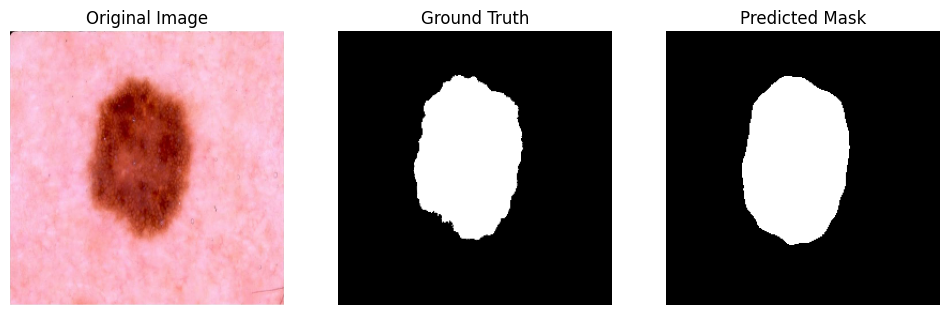

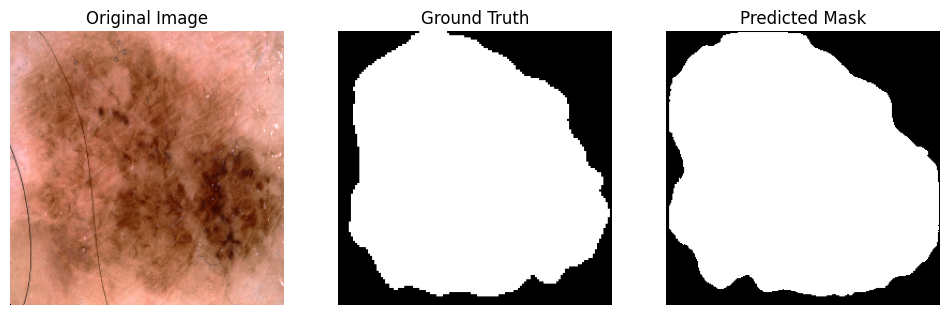

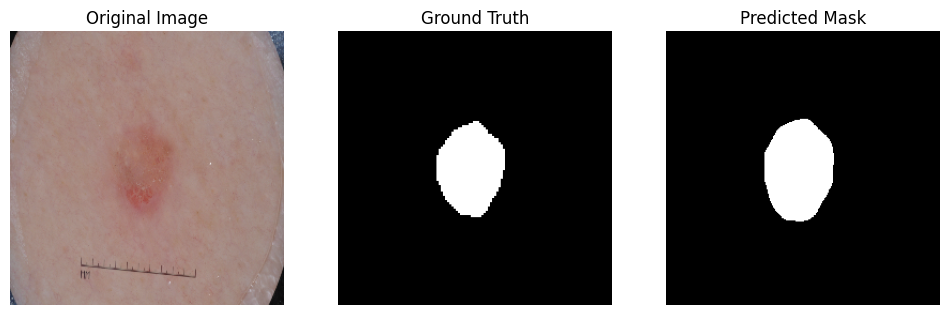

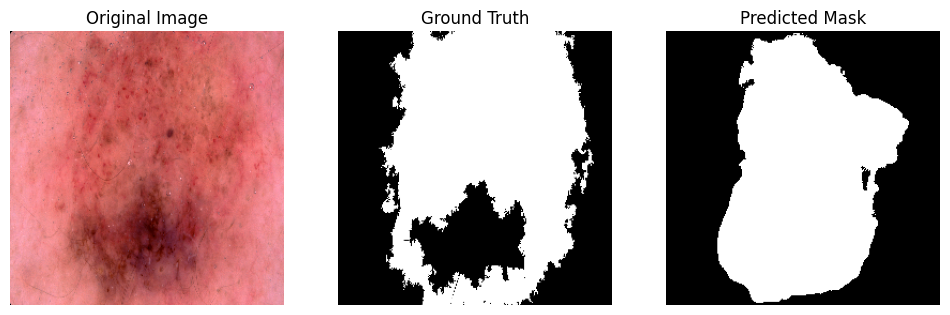

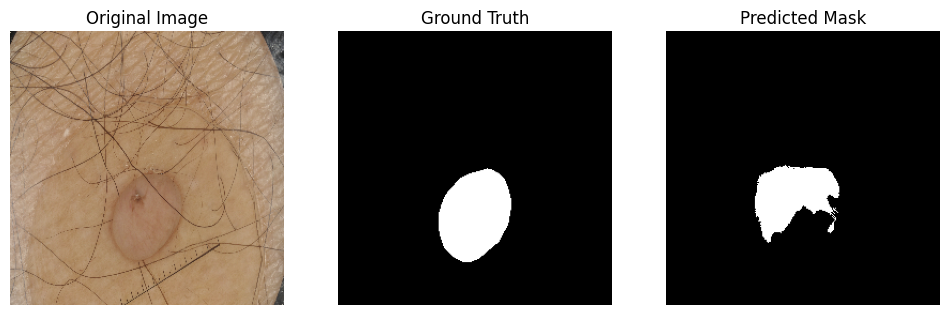

In [20]:
# Function to visualize predictions

def visualize_predictions(dataset, model, num_samples=5):
    for images, masks in dataset.take(1):
        preds = model.predict(images)

        for i in range(num_samples):
            plt.figure(figsize=(12,4))

            # Original Image
            plt.subplot(1,3,1)
            plt.imshow(images[i])
            plt.title("Original Image")
            plt.axis("off")

            # Ground Truth
            plt.subplot(1,3,2)
            plt.imshow(tf.squeeze(masks[i]), cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            # Predicted Mask
            plt.subplot(1,3,3)
            plt.imshow(tf.squeeze(preds[i]) > 0.5, cmap="gray")
            plt.title("Predicted Mask")
            plt.axis("off")

            plt.show()

# Visualize
visualize_predictions(val_dataset, model)

In [21]:
# Compute Precision and Recall manually

def precision_metric(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    return tp / (tp + fp + 1e-6)

def recall_metric(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    return tp / (tp + fn + 1e-6)

# Evaluate on validation set
results = model.evaluate(val_dataset)

print("Validation Results:")
print("Loss:", results[0])
print("Dice:", results[1])
print("IoU:", results[2])

65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 335ms/step - dice_coefficient: 0.8178 - iou_metric: 0.6972 - loss: 0.3692
Validation Results:
Loss: 0.38637304306030273
Dice: 0.8091702461242676
IoU: 0.6864256262779236


Brightness-Augmented Dataset

In [22]:
def load_image_mask_brightness(img_name, mask_name):
    img_path = tf.strings.join([train_img_dir, "/", img_name])
    mask_path = tf.strings.join([train_mask_dir, "/", mask_name])

    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    # Apply brightness augmentation
    img = tf.image.random_brightness(img, max_delta=0.2)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def create_dataset_brightness(img_list, mask_list):
    dataset = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    dataset = dataset.map(load_image_mask_brightness, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


train_dataset_bright = create_dataset_brightness(train_imgs, train_masks)

In [23]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Build NEW Model

In [24]:
model_bright = build_unet()

model_bright.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=lambda y_true, y_pred: tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred),
    metrics=[dice_coefficient, iou_metric]
)

In [27]:
print("Training started...")

history_bright = model_bright.fit(
    train_dataset_bright,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

print("Training finished.")

Training started...
Epoch 1/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 109s 414ms/step - dice_coefficient: 0.8412 - iou_metric: 0.7291 - loss: 0.2984 - val_dice_coefficient: 0.8057 - val_iou_metric: 0.6832 - val_loss: 0.3838
Epoch 2/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 109s 417ms/step - dice_coefficient: 0.8503 - iou_metric: 0.7426 - loss: 0.2857 - val_dice_coefficient: 0.8093 - val_iou_metric: 0.6862 - val_loss: 0.3729
Epoch 3/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 109s 416ms/step - dice_coefficient: 0.8597 - iou_metric: 0.7563 - loss: 0.2668 - val_dice_coefficient: 0.7767 - val_iou_metric: 0.6459 - val_loss: 0.4539
Epoch 4/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 107s 412ms/step - dice_coefficient: 0.8648 - iou_metric: 0.7643 - loss: 0.2557 - val_dice_coefficient: 0.8297 - val_iou_metric: 0.7147 - val_loss: 0.3412
Epoch 5/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 110s 422ms/step - dice_coefficient: 0.8750 - iou_metric: 0.7796 - loss: 0.2367 - val_dice_coefficient: 0.8102 - val_iou_metric: 0.6891 - val_loss: 0.4042
Training finish

In [28]:
import numpy as np

def evaluate_segmentation_metrics(model, dataset):
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for images, masks in dataset:
        preds = model.predict(images, verbose=0)
        preds = (preds > 0.5).astype(np.float32)

        masks = masks.numpy()

        tp = np.sum(preds * masks)
        fp = np.sum(preds * (1 - masks))
        fn = np.sum((1 - preds) * masks)

        total_tp += tp
        total_fp += fp
        total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)

    return precision, recall

In [32]:
print("hi")
precision_base, recall_base = evaluate_segmentation_metrics(model, val_dataset)
precision_bright, recall_bright = evaluate_segmentation_metrics(model_bright, val_dataset)

print("Baseline Precision:", precision_base)
print("Baseline Recall:", recall_base)

print("Brightness Precision:", precision_bright)
print("Brightness Recall:", recall_bright)

hi
Baseline Precision: 0.8910493
Baseline Recall: 0.8068278
Brightness Precision: 0.8944475
Brightness Recall: 0.83451366
